# Computing solar heating from observations

In [1]:
import os
os.environ['PROJ_LIB'] = '/glade/u/home/asiddiqui/miniconda3/share/proj'

In [2]:
# remove temp dask worker files
!rm -f dask*

In [3]:
%load_ext watermark

import cf_xarray as cfxr
import dask_jobqueue
import distributed
import intake
import intake_esm
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pint_xarray
from matplotlib.ticker import FormatStrFormatter
import xarray as xr
from cf_xarray.units import units
from matplotlib.patches import FancyBboxPatch# loads some UDUNITS definitions
import xeofs
import pop_tools
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


import xarray as xr
import seaborn as sns
from matplotlib.gridspec import GridSpec
from cartopy.crs import Robinson, PlateCarree

from xeofs.models import MCA, MCARotator

import cmocean
from matplotlib.patches import Polygon
%matplotlib inline

import warnings

import matplotlib.path                 as mpath
import cartopy.crs                     as ccrs
import cartopy.mpl.ticker              as ctk
import cartopy.feature as cfeature
import cartopy.mpl.patch as cpatch
import matplotlib as mpl

import shapely
import geopandas as gpd
import salem
import regionmask
import pandas as pd
from matplotlib.ticker import AutoMinorLocator

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


import intake
import matplotlib.pyplot as plt
import xarray as xr
from distributed import Client
from ncar_jobqueue import NCARCluster
import itertools


import cartopy.feature as cfeature
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                        edgecolor='face',
                                        facecolor=cfeature.COLORS['land'])

xr.set_options(keep_attrs=True)

%watermark -iv

seaborn      : 0.12.2
cmocean      : 3.0.3
pandas       : 2.0.2
sys          : 3.10.12 | packaged by conda-forge | (main, Jun 23 2023, 22:40:32) [GCC 12.3.0]
xarray       : 2023.6.0
intake       : 0.7.0
dask_jobqueue: 0.8.2
numpy        : 1.23.5
pint_xarray  : 0.3
distributed  : 2023.6.0
cartopy      : 0.21.1
cf_xarray    : 0.8.2
xeofs        : 1.0.3
salem        : 0.3.10
pop_tools    : 2023.3.0
intake_esm   : 2023.6.14
regionmask   : 0.12.1
shapely      : 2.0.1
matplotlib   : 3.7.1
geopandas    : 0.13.2



/glade/derecho/scratch/asiddiqui/tmp/ipykernel_9671/1588018898.py:46: DeprecationWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas still uses PyGEOS by default. However, starting with version 0.14, the default will switch to Shapely. To force to use Shapely 2.0 now, you can either uninstall PyGEOS or set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In the next release, GeoPandas will switch to using Shapely by default, even if PyGEOS is installed. If you only have PyGEOS installed to get speed-ups, this switch should be smooth. However, if you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


In [4]:
import matplotlib.pylab as pylab

pylab.rcParams.update({
  "text.usetex": True
})
plt.rcParams['font.family'] = 'Sans Serif'
plt.rcParams['font.serif'] = ['Helvetica']

### Reading the monthly mean data for NSIDC and AVHRR

In [5]:
ds_avhrr = xr.open_dataset('../data_files/avhrr_monthly_means.nc').sel(time=slice('1982-01','2022-12'))
ds_avhrr

<xarray.Dataset>
Dimensions:                                 (time: 492, x: 304, y: 448)
Coordinates:
  * time                                    (time) datetime64[ns] 1982-01-31 ...
    xgrid                                   (x) float32 ...
    ygrid                                   (y) float32 ...
    longitude                               (y, x) float32 ...
    latitude                                (y, x) float32 ...
Dimensions without coordinates: x, y
Data variables:
    cdr_surface_albedo                      (time, y, x) float32 ...
    cdr_surface_downwelling_shortwave_flux  (time, y, x) float32 ...

In [6]:
ds_nsidc = xr.open_dataset('../data_files/NSIDC_monthly.nc').sel(time=slice('1982-01','2022-12'))
ds_nsidc

<xarray.Dataset>
Dimensions:          (time: 492, y: 448, x: 304)
Coordinates:
    xgrid            (x) float32 ...
    ygrid            (y) float32 ...
    latitude         (y, x) float32 ...
    longitude        (y, x) float32 ...
  * time             (time) datetime64[ns] 1982-01-31 1982-02-28 ... 2022-12-31
Dimensions without coordinates: y, x
Data variables:
    cdr_seaice_conc  (time, y, x) float32 ...
Attributes: (12/39)
    Conventions:               CF-1.6, ACDD-1.3
    title:                     NOAA/NSIDC Climate Data Record of Passive Micr...
    references:                Comiso, J. C., and F. Nishio. 2008. Trends in ...
    comment:                   none
    program:                   NOAA Climate Data Record Program
    cdr_variable:              cdr_seaice_conc
    ...                        ...
    acknowledgment:            This project was supported in part by a grant ...
    platform:                  NIMBUS-7
    sensor:                    SMMR > Scanning Multichannel Microwave Radiometer
    date_created:              2021-06-21T17:19:22Z
    time_coverage_start:       1982-01-01T00:00:00Z
    time_coverage_end:         1982-12-31T23:59:59Z

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 4.05 µs


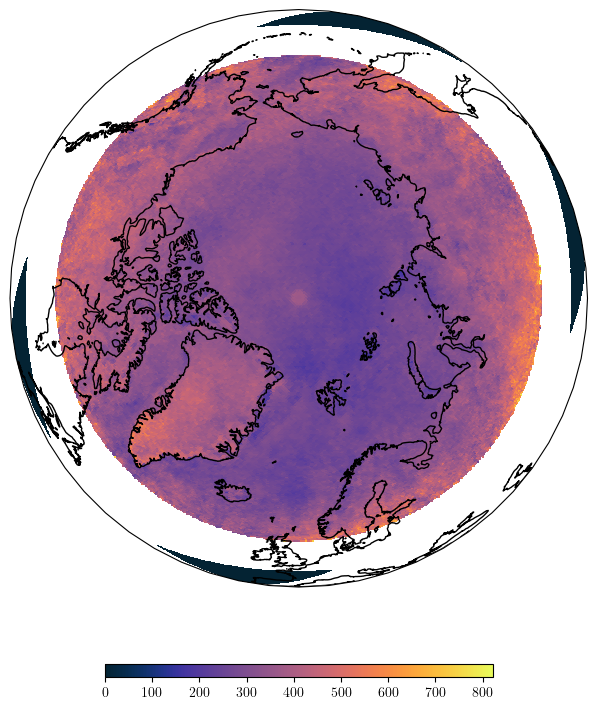

In [7]:
%time

name='NearsidePerspective'
proj=ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)


# Define the figure and each axis for the 3 rows and 3 columns
fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(10,10))

# ax = ax.flatten()

cf = ax.pcolormesh(ds_avhrr.longitude, ds_avhrr.latitude, ds_avhrr['cdr_surface_downwelling_shortwave_flux'].sel(time='1983-6').squeeze() ,  cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree())

ax.coastlines()
# ax.add_feature(land_50m, facecolor='grey')
# Draw the colorbar
cbar = fig.colorbar(cf, ax=ax, shrink = 0.5, aspect = 30 , pad = 0.1 , orientation='horizontal')

### Creating the area mask 

In [8]:
mask = xr.ones_like(ds_nsidc.latitude).where(ds_nsidc.latitude>66)
mask = mask.where(ds_nsidc.cdr_seaice_conc.sel(time='2002-06').squeeze()>=0)

In [9]:
ds_avhrr = ds_avhrr.where(mask==1)

CPU times: user 1 µs, sys: 1e+03 ns, total: 2 µs
Wall time: 4.53 µs


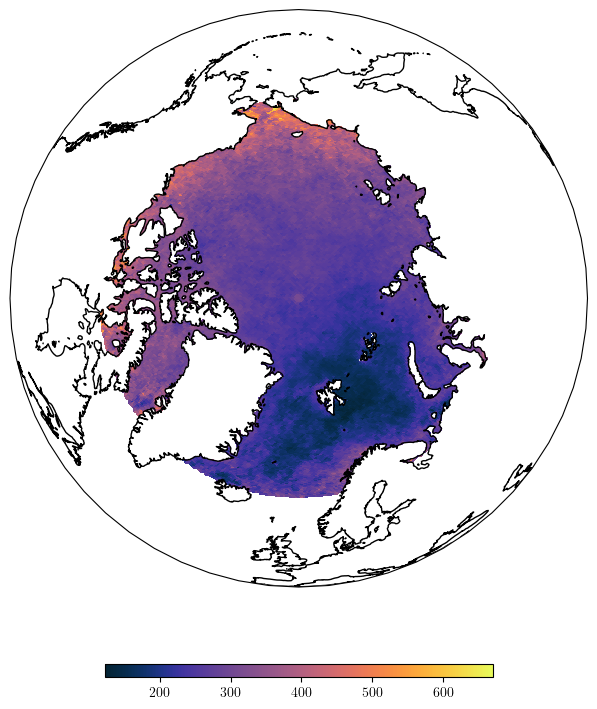

In [10]:
%time

name='NearsidePerspective'
proj=ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)


# Define the figure and each axis for the 3 rows and 3 columns
fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(10,10))

# ax = ax.flatten()

cf = ax.pcolormesh(ds_avhrr.longitude, ds_avhrr.latitude, 
                   ds_avhrr.cdr_surface_downwelling_shortwave_flux.sel(time='1986-5').squeeze(),
                   cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree())

ax.coastlines()
# ax.add_feature(land_50m, facecolor='grey')
# Draw the colorbar
cbar = fig.colorbar(cf, ax=ax, shrink = 0.5, aspect = 30 , pad = 0.1 , orientation='horizontal')

### Following Stroeve et al 2014

Using APP-X estimates of α and *F*<sub>r</sub>, the flux of solar heat input to the ice/ocean system (*F*<sub>in</sub>) over time (*t*) can be written as  

$$
F_{in}(t) = F_r(t)\,[1 - \alpha_i(t)] \tag{1}
$$

The total amount of energy absorbed by the ice/ocean system is then defined as  

$$
Q_{\text{total}} = \sum F_r(t)\,[1 - \alpha(t)]\,\Delta t \tag{2}
$$

where time is in monthly increments, averaged from May through September.


In [11]:
ds_avhrr['solar_abs'] = ds_avhrr['cdr_surface_downwelling_shortwave_flux']*(1-ds_avhrr['cdr_surface_albedo'])

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 4.53 µs


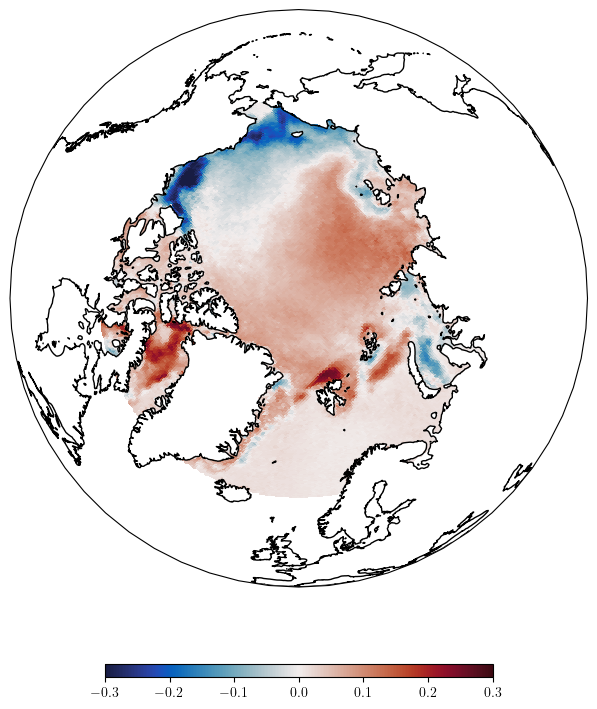

In [12]:
%time

name='NearsidePerspective'
proj=ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)


# Define the figure and each axis for the 3 rows and 3 columns
fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(10,10))

# ax = ax.flatten()

cf = ax.pcolormesh(ds_avhrr.longitude, ds_avhrr.latitude, 
                   ds_avhrr['cdr_surface_albedo'].sel(time='1993-7').squeeze()-
                   ds_avhrr['cdr_surface_albedo'].sel(time='1994-7').squeeze() ,
                   vmin=-.3, vmax=.3, 
                   cmap=cmocean.cm.balance, transform=ccrs.PlateCarree())

ax.coastlines()
# ax.add_feature(land_50m, facecolor='grey')
# Draw the colorbar
cbar = fig.colorbar(cf, ax=ax, shrink = 0.5, aspect = 30 , pad = 0.1 , orientation='horizontal')

Creating the mask for area over which the heating is computed

In [13]:
# Suppose your dataset is named ds
x = ds_nsidc['xgrid']
y = ds_nsidc['ygrid']

# 1️⃣ Compute grid spacing (in meters)
dx = np.abs(ds_nsidc.xgrid.diff('x').mean().item())
dy = np.abs(ds_nsidc.ygrid.diff('y').mean().item())

print(f"Grid spacing: dx={dx:.1f} m, dy={dy:.1f} m")

# 2️⃣ Compute grid cell area
cell_area = dx * dy  # in m²


# 3️⃣ Create area array with same shape as your 2D field
area = xr.full_like(ds_nsidc['latitude'], cell_area)
area.attrs['units'] = 'm2'
area.attrs['description'] = 'Grid cell area (computed from xgrid, ygrid)'

# Now area(y, x) matches your data grid


Grid spacing: dx=25000.0 m, dy=25000.0 m


In [14]:
# writing down the variables that we're gonna use to construct the terms

#shortwave 
sw_avg = ds_avhrr['cdr_surface_downwelling_shortwave_flux'].sel(time=slice('1982-01','2002-12')).groupby('time.month').mean('time')
sw = ds_avhrr['cdr_surface_downwelling_shortwave_flux']
sw_ref = sw.sel(time=slice('1982-01','2002-12')).groupby('time.month').mean('time')
sw_change = sw.groupby('time.month') - sw_ref

# sea ice albedo
sialb = ds_avhrr['cdr_surface_albedo'].where(ds_nsidc['cdr_seaice_conc']>0.15)
alb_i_avg = sialb.sel(time=slice('1982-01','2002-12')).groupby('time.month').mean('time')
alb_i = sialb
alb_i_ref = alb_i.sel(time=slice('1982-01','2002-12')).groupby('time.month').mean('time')
alb_i_change = alb_i.groupby('time.month') - alb_i_ref

#seawater albedo
alb_w_avg = 0.07

# sea ice concentration
aice = ds_nsidc.cdr_seaice_conc.where(mask==1)
aice_avg = aice.sel(time=slice('1982-01','2002-12')).groupby('time.month').mean('time')

aice_ref = aice.sel(time=slice('1982-01','2002-12')).groupby('time.month').mean('time')
aice_change = aice.groupby('time.month') - aice_ref

# sw_abs
sw_abs = (ds_avhrr['cdr_surface_downwelling_shortwave_flux']*(1-ds_avhrr['cdr_surface_albedo']))
sw_abs_ref = sw_abs.sel(time=slice('1982-01','2002-12')).groupby('time.month').mean('time')
sw_abs_change = sw_abs.groupby('time.month') - sw_abs_ref


In [15]:
area  = area.where(mask==1)
area = area.where(aice.sel(time='2002-06').squeeze()>=0)

CPU times: user 1e+03 ns, sys: 0 ns, total: 1e+03 ns
Wall time: 4.05 µs


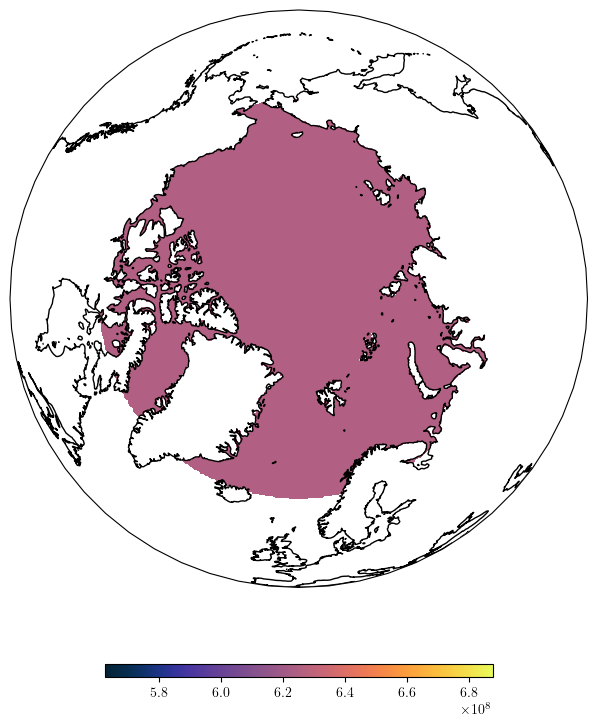

In [16]:
%time

name='NearsidePerspective'
proj=ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)


# Define the figure and each axis for the 3 rows and 3 columns
fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(10,10))

# ax = ax.flatten()

cf = ax.pcolormesh(ds_nsidc.longitude, ds_nsidc.latitude, area ,  cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree())

ax.coastlines()
# ax.add_feature(land_50m, facecolor='grey')
# Draw the colorbar
cbar = fig.colorbar(cf, ax=ax, shrink = 0.5, aspect = 30 , pad = 0.1 , orientation='horizontal')

CPU times: user 2 µs, sys: 1 µs, total: 3 µs
Wall time: 3.81 µs


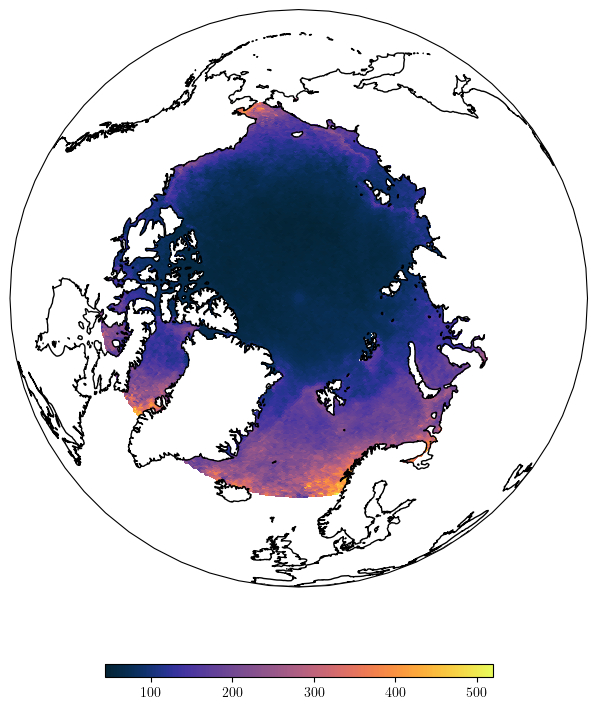

In [17]:
%time

name='NearsidePerspective'
proj=ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)


# Define the figure and each axis for the 3 rows and 3 columns
fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(10,10))

# ax = ax.flatten()

cf = ax.pcolormesh(ds_avhrr.longitude, ds_avhrr.latitude, sw_abs.sel(time='2002-05').squeeze() ,  cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree())

ax.coastlines()
# ax.add_feature(land_50m, facecolor='grey')
# Draw the colorbar
cbar = fig.colorbar(cf, ax=ax, shrink = 0.5, aspect = 30 , pad = 0.1 , orientation='horizontal')

### Absorbed shortwave $Q_{\downarrow}^\prime$

In [18]:
SW_abs = sw_abs_change

In [19]:
# area and concentration weighted value
SW_abs_num = (SW_abs*area).sum(('x','y'), skipna=True)
SW_abs_den = (area).sum(('x','y'), skipna=True)
SW_abs_sum = SW_abs_num/SW_abs_den

In [20]:
ds_sw_abs = SW_abs_sum.to_dataset(name='sw_abs')
ds_sw_abs

<xarray.Dataset>
Dimensions:  (time: 492)
Coordinates:
  * time     (time) datetime64[ns] 1982-01-31 1982-02-28 ... 2022-12-31
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    sw_abs   (time) float32 0.0 0.0 0.0 3.709 -5.396 ... 27.91 1.493 0.0 0.0 0.0

In [21]:
# ds_sw_abs.to_netcdf('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/SW_absorbed_obs.nc')

Text(0, 0.5, 'SW absorbed')

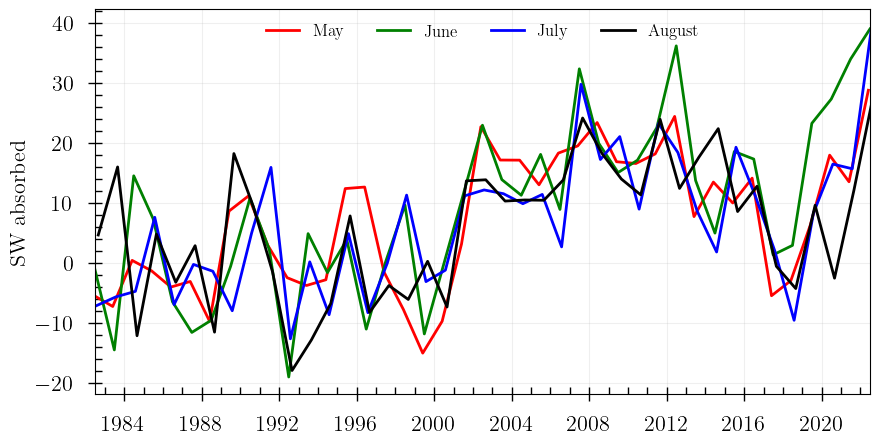

In [22]:
fig, ax  = plt.subplots(figsize=(10,5))


ax.plot(SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[5]).time, SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[5]), c='r', lw=2, label='May')
ax.plot(SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[6]).time, SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[6]), c='g', lw=2,label='June')
ax.plot(SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[7]).time, SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[7]), c='b', lw=2,label='July')
ax.plot(SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[8]).time, SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[8]), c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='upper center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))
# ax.set_ylim(-15,80)
ax.set_ylabel('SW absorbed', fontsize=16)


# plt.savefig('figs/sw_abs.png', format='png', bbox_inches='tight', dpi=300)


#### Surface shortwave

In [23]:
# area and concentration weighted value
SW_num = (sw*area).sum(('x','y'), skipna=True)
SW_den = (area).sum(('x','y'), skipna=True)
SW_sum = SW_num/SW_den

In [24]:
ds_sw = SW_sum.to_dataset(name='sw_dn')
ds_sw

<xarray.Dataset>
Dimensions:  (time: 492)
Coordinates:
  * time     (time) datetime64[ns] 1982-01-31 1982-02-28 ... 2022-12-31
Data variables:
    sw_dn    (time) float32 0.0 0.0 0.0 183.8 287.6 ... 159.1 11.49 0.0 0.0 0.0

In [25]:
# ds_sw.to_netcdf('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/warming_terms_sw_dn_obs.nc')

Text(0, 0.5, 'SW dn')

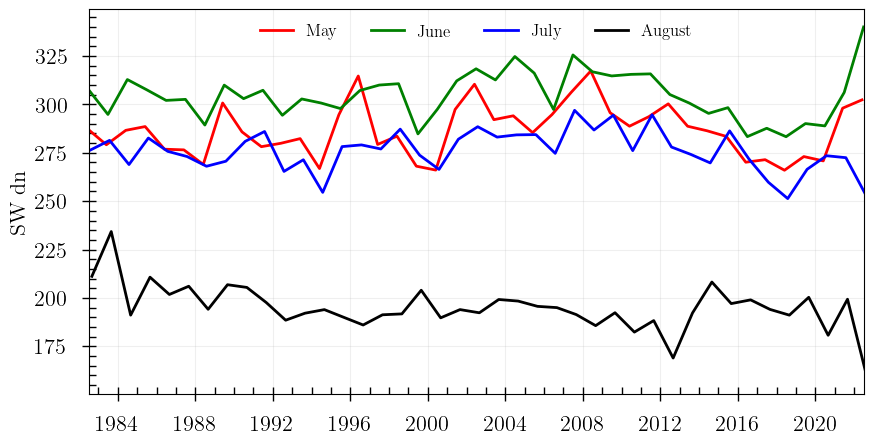

In [26]:
fig, ax  = plt.subplots(figsize=(10,5))


ax.plot(SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[5]).time, SW_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[5]), c='r', lw=2, label='May')
ax.plot(SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[6]).time, SW_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[6]), c='g', lw=2,label='June')
ax.plot(SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[7]).time, SW_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[7]), c='b', lw=2,label='July')
ax.plot(SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[8]).time, SW_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[8]), c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='upper center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))
# ax.set_ylim(-15,80)
ax.set_ylabel('SW dn', fontsize=16)


# plt.savefig('figs/sw_abs.png', format='png', bbox_inches='tight', dpi=300)


Text(0, 0.5, 'SW dn')

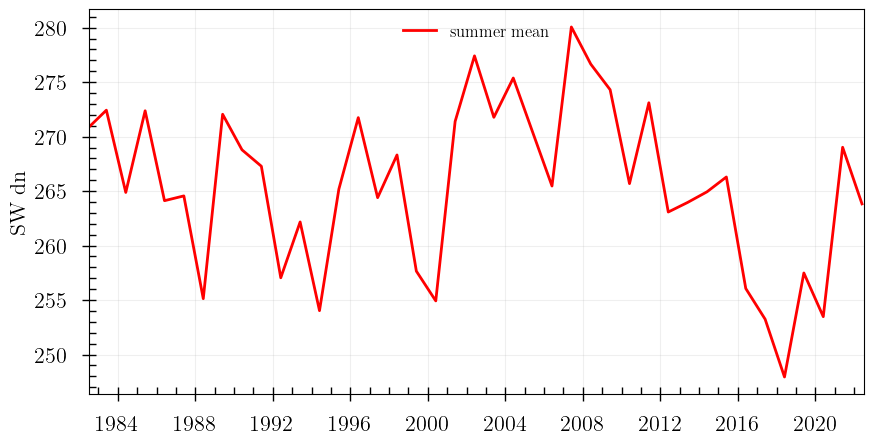

In [27]:
fig, ax  = plt.subplots(figsize=(10,5))


ax.plot(SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[5]).time, SW_sum.sel(time=SW_sum['time.month'].isin([5,6,7,8])).groupby('time.year').mean(dim='time'), c='r', lw=2, label='summer mean')

ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='upper center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            SW_abs_sum.isel(time=(SW_abs_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))
# ax.set_ylim(-15,80)
ax.set_ylabel('SW dn', fontsize=16)


# plt.savefig('figs/sw_abs.png', format='png', bbox_inches='tight', dpi=300)


### I = $\overline{Q_{sw}}C^\prime (\alpha_w  - \overline{\alpha_{i}})$

In [28]:
I = aice_change.groupby('time.month') * (sw_avg * (alb_w_avg - alb_i_avg))

In [29]:
# area and concentration weighted value
I_num = (I*area).sum(('x','y'), skipna=True)
I_den = (area).sum(('x','y'), skipna=True)
I_sum = I_num/I_den

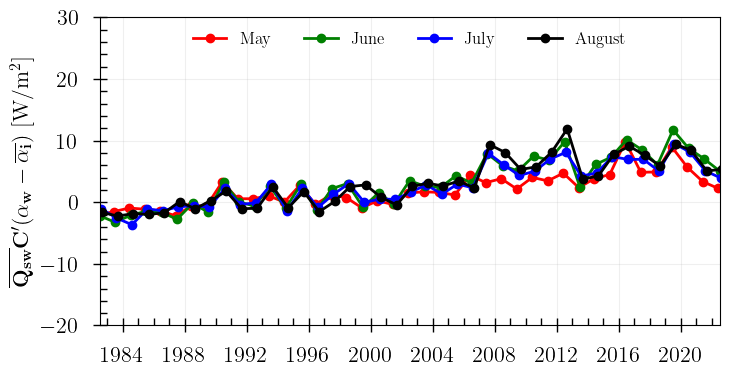

In [89]:
fig, ax  = plt.subplots(figsize=(8,4))


ax.plot(I_sum.isel(time=(I_sum.groupby('time.month').groups)[5]).time, I_sum.isel(time=(I_sum.groupby('time.month').groups)[5]), '-o', c='r',  lw=2, label='May')
ax.plot(I_sum.isel(time=(I_sum.groupby('time.month').groups)[6]).time, I_sum.isel(time=(I_sum.groupby('time.month').groups)[6]), '-o',c='g', lw=2,label='June')
ax.plot(I_sum.isel(time=(I_sum.groupby('time.month').groups)[7]).time, I_sum.isel(time=(I_sum.groupby('time.month').groups)[7]), '-o',c='b', lw=2,label='July')
ax.plot(I_sum.isel(time=(I_sum.groupby('time.month').groups)[8]).time, I_sum.isel(time=(I_sum.groupby('time.month').groups)[8]), '-o',c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='upper center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(I_sum.isel(time=(I_sum.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            I_sum.isel(time=(I_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))
ax.set_ylim(-20,30)
ax.set_ylabel(r'$\mathbf{\overline{Q_{sw}}C^\prime (\alpha_w  - \overline{\alpha_{i}})}$ [W/m$^2]$', fontsize=16)

plt.savefig('../figs/term_1_obs.png', format='png', bbox_inches='tight', dpi=300)


### II = -$\overline{Q_{sw}} \; \overline{C}\alpha_{i}^\prime$

In [31]:
II = alb_i_change.groupby('time.month') * (sw_avg * aice_avg)

In [32]:
# area and concentration weighted value
II_num = (II*area).sum(('x','y'), skipna=True)
II_den = (area).sum(('x','y'), skipna=True)
II_sum = II_num/II_den

In [33]:
II_sum = -II_sum.load()

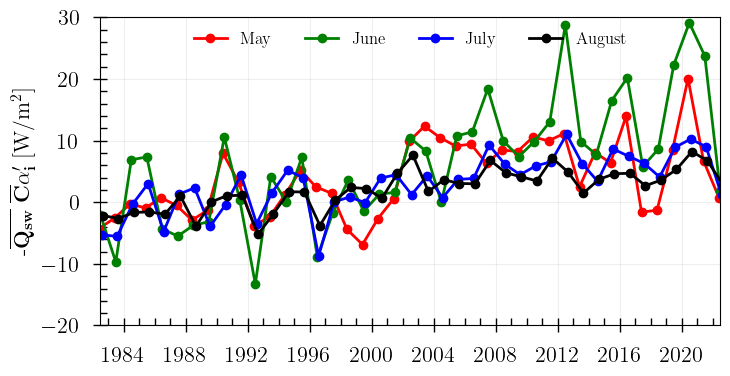

In [88]:
fig, ax  = plt.subplots(figsize=(8,4))

ax.plot(II_sum.isel(time=(II_sum.groupby('time.month').groups)[5]).time, II_sum.isel(time=(II_sum.groupby('time.month').groups)[5]), '-o', c='r', lw=2, label='May')
ax.plot(II_sum.isel(time=(II_sum.groupby('time.month').groups)[6]).time, II_sum.isel(time=(II_sum.groupby('time.month').groups)[6]), '-o',c='g', lw=2,label='June')
ax.plot(II_sum.isel(time=(II_sum.groupby('time.month').groups)[7]).time, II_sum.isel(time=(II_sum.groupby('time.month').groups)[7]), '-o',c='b', lw=2,label='July')
ax.plot(II_sum.isel(time=(II_sum.groupby('time.month').groups)[8]).time, II_sum.isel(time=(II_sum.groupby('time.month').groups)[8]), '-o',c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='upper center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(II_sum.isel(time=(II_sum.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            II_sum.isel(time=(II_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))
ax.set_ylim(-20,30)

ax.set_ylabel(r'-$\mathbf{\overline{Q_{sw}} \; \overline{C}\alpha_{i}^\prime}$ [W/m$^2$]', fontsize=16)


plt.savefig('../figs/term_2_obs.png', format='png', bbox_inches='tight', dpi=300)

### III = -$\overline{Q_{sw}}(C^\prime \alpha_{i}^\prime - \overline{C^\prime \alpha_i^\prime })$


In [35]:
cprime_alphaprime = (aice_change*alb_i_change)
cprime_alphaprime_mean = cprime_alphaprime.groupby('time.month').mean('time')
cprime_alphaprime_anom = cprime_alphaprime.groupby('time.month') - cprime_alphaprime_mean

III = cprime_alphaprime_anom.groupby('time.month')*sw_avg

In [36]:
# area and concentration weighted value
III_num = (III*area).sum(('x','y'), skipna=True)
III_den = (area).sum(('x','y'), skipna=True)
III_sum = III_num/III_den

In [37]:
III_sum = -III_sum.load()

Text(0, 0.5, '$\\mathbf{-C^\\prime \\alpha_{i}^\\prime + \\overline{C^\\prime \\alpha_i^\\prime}}$ [W/m$^2$]')

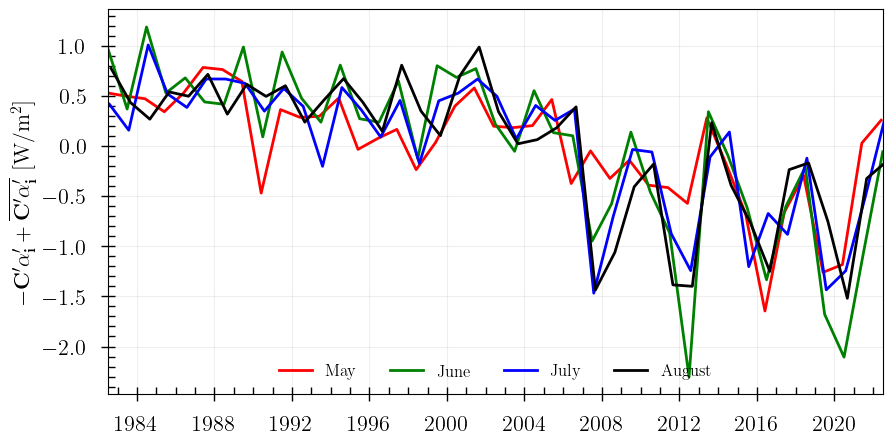

In [38]:
fig, ax  = plt.subplots(figsize=(10,5))



ax.plot(III_sum.isel(time=(III_sum.groupby('time.month').groups)[5]).time, III_sum.isel(time=(III_sum.groupby('time.month').groups)[5]), c='r', lw=2, label='May')
ax.plot(III_sum.isel(time=(III_sum.groupby('time.month').groups)[6]).time, III_sum.isel(time=(III_sum.groupby('time.month').groups)[6]), c='g', lw=2,label='June')
ax.plot(III_sum.isel(time=(III_sum.groupby('time.month').groups)[7]).time, III_sum.isel(time=(III_sum.groupby('time.month').groups)[7]), c='b', lw=2,label='July')
ax.plot(III_sum.isel(time=(III_sum.groupby('time.month').groups)[8]).time, III_sum.isel(time=(III_sum.groupby('time.month').groups)[8]), c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='lower center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(III_sum.isel(time=(III_sum.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            III_sum.isel(time=(III_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))
# ax.set_ylim(-40, 15)

ax.set_ylabel(r'$\mathbf{-C^\prime \alpha_{i}^\prime + \overline{C^\prime \alpha_i^\prime}}$ [W/m$^2$]', fontsize=16)


# plt.savefig('figs/term_3.png', format='png', bbox_inches='tight', dpi=300)

### IV = $Q_{sw}^\prime ( 1- \alpha_w)$


In [39]:
I_V = sw_change*(1-alb_w_avg)

In [40]:
# area and concentration weighted value
I_V_num = (I_V*area).sum(('x','y'), skipna=True)
I_V_den = (area).sum(('x','y'), skipna=True)
I_V_sum = I_V_num/I_V_den

In [41]:
I_V_sum = I_V_sum.load()

Text(0, 0.5, '$\\mathbf{Q_{sw}^\\prime ( 1- \\alpha_w)}$ [W/m$^2$]')

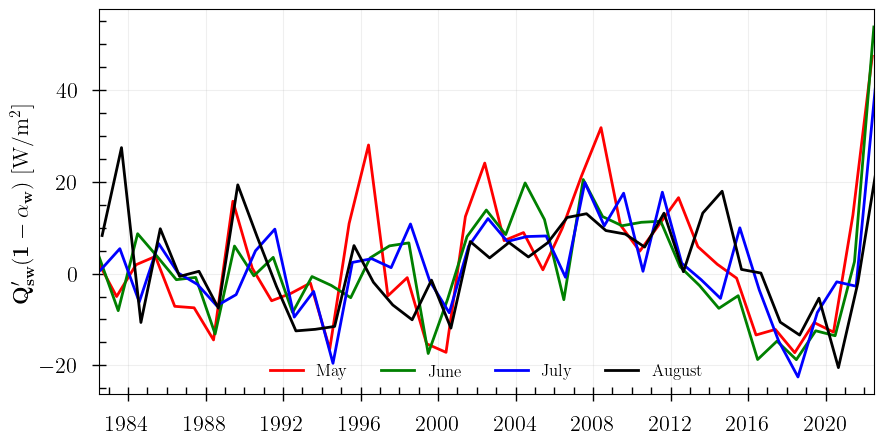

In [42]:
fig, ax  = plt.subplots(figsize=(10,5))


ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]), c='r', lw=2, label='May')
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]), c='g', lw=2,label='June')
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]), c='b', lw=2,label='July')
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]), c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='lower center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))

# ax.set_ylim(-80,80)

ax.set_ylabel(r'$\mathbf{Q_{sw}^\prime ( 1- \alpha_w)}$ [W/m$^2$]', fontsize=16)

# plt.savefig('figs/term_4.png', format='png', bbox_inches='tight', dpi=300)

### V = $Q_{sw}^\prime\overline{C} (\alpha_w - \overline{\alpha_i}) $

In [43]:
V = sw_change.groupby('time.month')*(aice_avg*(alb_w_avg-alb_i_avg))

In [44]:
# area and concentration weighted value
V_num = (V*area).sum(('x','y'), skipna=True)
V_den = (area).sum(('x','y'), skipna=True)
V_sum = V_num/V_den

In [45]:
V_sum = V_sum.load()

Text(0, 0.5, '$\\mathbf{Q_{sw}^\\prime\\overline{C} (\\alpha_w - \\overline{\\alpha_i})} $ [W/m$^2$]')

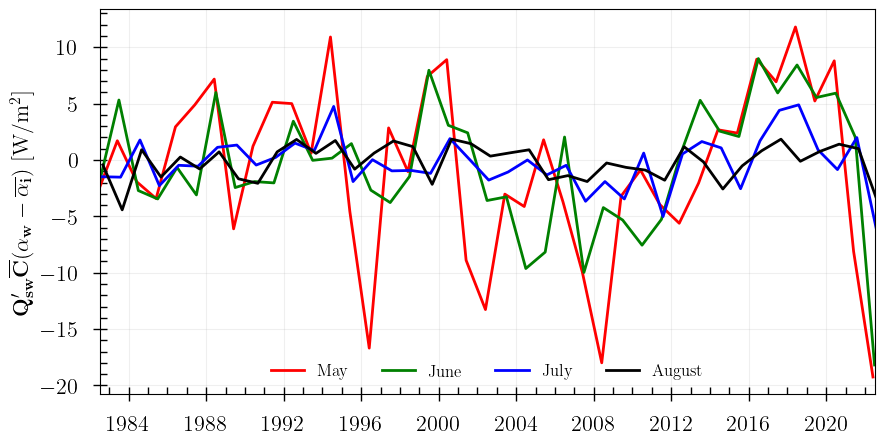

In [46]:
fig, ax  = plt.subplots(figsize=(10,5))



ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[5]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[5]), c='r', lw=2, label='May')
ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]), c='g', lw=2,label='June')
ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[7]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[7]), c='b', lw=2,label='July')
ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[8]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[8]), c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='lower center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))



ax.set_ylabel(r'$\mathbf{Q_{sw}^\prime\overline{C} (\alpha_w - \overline{\alpha_i})} $ [W/m$^2$]', fontsize=16)

# plt.savefig('figs/term_5.png', format='png', bbox_inches='tight', dpi=300)

### VI = $(Q_{sw}^\prime C^\prime(\alpha_w - \overline{\alpha_i}))^\prime$


In [47]:
cprime_alphaprime = ((sw_change*aice_change).groupby('time.month'))*(alb_w_avg-alb_i_avg)
cprime_alphaprime_mean = cprime_alphaprime.groupby('time.month').mean('time')
cprime_alphaprime_anom = cprime_alphaprime.groupby('time.month') - cprime_alphaprime_mean

V_I = cprime_alphaprime_anom

In [48]:
# area and concentration weighted value
V_I_num = (V_I*area).sum(('x','y'), skipna=True)
V_I_den = (area).sum(('x','y'), skipna=True)
V_I_sum = V_I_num/V_I_den

In [49]:
V_I_sum = V_I_sum.load()

Text(0, 0.5, '$\\mathbf{(Q_{sw}^\\prime C^\\prime(\\alpha_w - \\overline{\\alpha_i}))^\\prime}$ [W/m$^2$]')

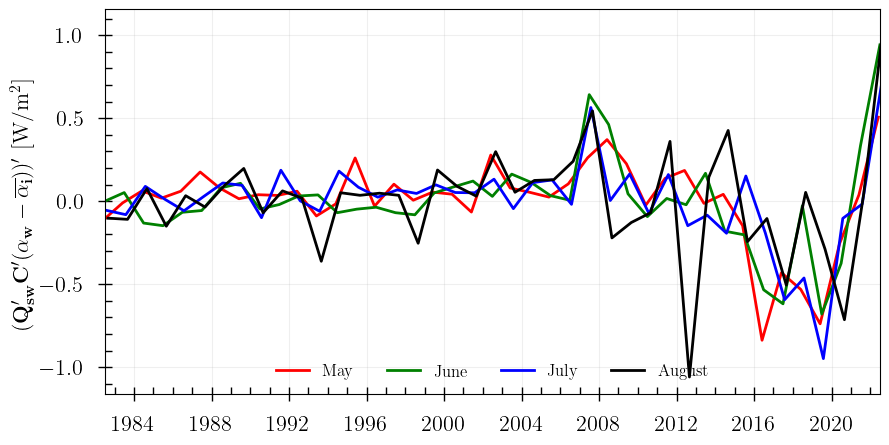

In [50]:
fig, ax  = plt.subplots(figsize=(10,5))


ax.plot(V_I_sum.isel(time=(V_I_sum.groupby('time.month').groups)[5]).time, V_I_sum.isel(time=(V_I_sum.groupby('time.month').groups)[5]), c='r', lw=2, label='May')
ax.plot(V_I_sum.isel(time=(V_I_sum.groupby('time.month').groups)[6]).time, V_I_sum.isel(time=(V_I_sum.groupby('time.month').groups)[6]), c='g', lw=2,label='June')
ax.plot(V_I_sum.isel(time=(V_I_sum.groupby('time.month').groups)[7]).time, V_I_sum.isel(time=(V_I_sum.groupby('time.month').groups)[7]), c='b', lw=2,label='July')
ax.plot(V_I_sum.isel(time=(V_I_sum.groupby('time.month').groups)[8]).time, V_I_sum.isel(time=(V_I_sum.groupby('time.month').groups)[8]), c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='lower center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(V_I_sum.isel(time=(V_I_sum.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            V_I_sum.isel(time=(V_I_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))


ax.set_ylabel(r'$\mathbf{(Q_{sw}^\prime C^\prime(\alpha_w - \overline{\alpha_i}))^\prime}$ [W/m$^2$]', fontsize=16)

# plt.savefig('figs/term_6.png', format='png', bbox_inches='tight', dpi=300)

### VII = -$(Q_{sw}^\prime \overline{C}\alpha_{i}^\prime)^\prime$

In [51]:
cprime_alphaprime = ((sw_change*alb_i_change).groupby('time.month'))*aice_avg
cprime_alphaprime_mean = cprime_alphaprime.groupby('time.month').mean('time')
cprime_alphaprime_anom = cprime_alphaprime.groupby('time.month') - cprime_alphaprime_mean

V_II = -cprime_alphaprime_anom

In [52]:
# area and concentration weighted value
V_II_num = (V_II*area).sum(('x','y'), skipna=True)
V_II_den = (area).sum(('x','y'), skipna=True)
V_II_sum = V_II_num/V_II_den

In [53]:
V_II_sum = V_II_sum.load()

Text(0, 0.5, '-$\\mathbf{(Q_{sw}^\\prime \\overline{C}\\alpha_{i}^\\prime)^\\prime}$')

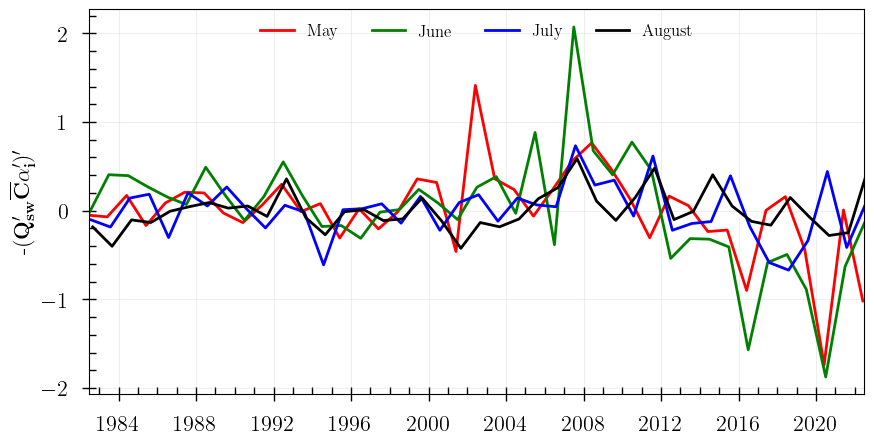

In [54]:
fig, ax  = plt.subplots(figsize=(10,5))

ax.plot(V_II_sum.isel(time=(V_II_sum.groupby('time.month').groups)[5]).time, V_II_sum.isel(time=(V_II_sum.groupby('time.month').groups)[5]), c='r', lw=2, label='May')
ax.plot(V_II_sum.isel(time=(V_II_sum.groupby('time.month').groups)[6]).time, V_II_sum.isel(time=(V_II_sum.groupby('time.month').groups)[6]), c='g', lw=2,label='June')
ax.plot(V_II_sum.isel(time=(V_II_sum.groupby('time.month').groups)[7]).time, V_II_sum.isel(time=(V_II_sum.groupby('time.month').groups)[7]), c='b', lw=2,label='July')
ax.plot(V_II_sum.isel(time=(V_II_sum.groupby('time.month').groups)[8]).time, V_II_sum.isel(time=(V_II_sum.groupby('time.month').groups)[8]), c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='upper center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(V_II_sum.isel(time=(V_II_sum.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            V_II_sum.isel(time=(V_II_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))

ax.set_ylabel(r'-$\mathbf{(Q_{sw}^\prime \overline{C}\alpha_{i}^\prime)^\prime}$', fontsize=16)

# plt.savefig('figs/term_7.png', format='png', bbox_inches='tight', dpi=300)

### VIII = $-(Q_{sw}^\prime C^\prime \alpha_{i}^\prime)^\prime$


In [55]:
cprime_alphaprime = (sw_change*aice_change*alb_i_change)
cprime_alphaprime_mean = cprime_alphaprime.groupby('time.month').mean('time')
cprime_alphaprime_anom = cprime_alphaprime.groupby('time.month') - cprime_alphaprime_mean

V_III = -cprime_alphaprime_anom

In [56]:
# area and concentration weighted value
V_III_num = (V_III*area).sum(('x','y'), skipna=True)
V_III_den = (area).sum(('x','y'), skipna=True)
V_III_sum = V_III_num/V_III_den

In [57]:
V_III_sum = V_III_sum.load()

Text(0, 0.5, '$-\\mathbf{(Q_{sw}^\\prime C^\\prime \\alpha_{i}^\\prime)^\\prime}$ [W/m$^2$]')

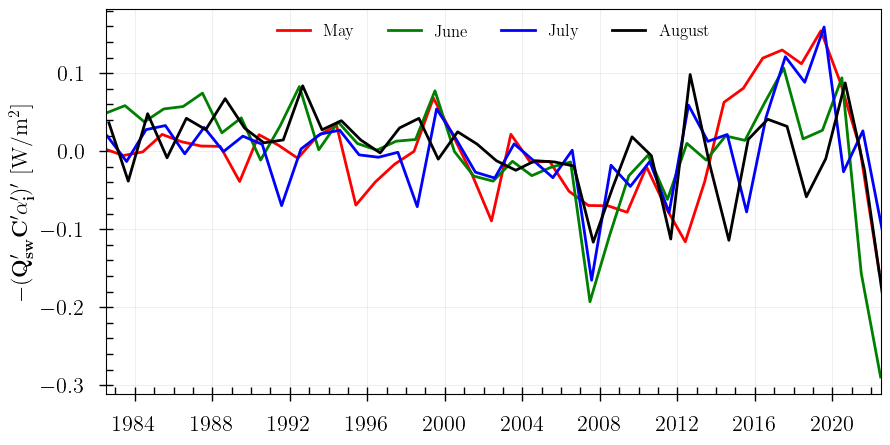

In [58]:
fig, ax  = plt.subplots(figsize=(10,5))


ax.plot(V_III_sum.isel(time=(V_III_sum.groupby('time.month').groups)[5]).time, V_III_sum.isel(time=(V_III_sum.groupby('time.month').groups)[5]), c='r', lw=2, label='May')
ax.plot(V_III_sum.isel(time=(V_III_sum.groupby('time.month').groups)[6]).time, V_III_sum.isel(time=(V_III_sum.groupby('time.month').groups)[6]), c='g', lw=2,label='June')
ax.plot(V_III_sum.isel(time=(V_III_sum.groupby('time.month').groups)[7]).time, V_III_sum.isel(time=(V_III_sum.groupby('time.month').groups)[7]), c='b', lw=2,label='July')
ax.plot(V_III_sum.isel(time=(V_III_sum.groupby('time.month').groups)[8]).time, V_III_sum.isel(time=(V_III_sum.groupby('time.month').groups)[8]), c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='upper center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(V_III_sum.isel(time=(V_III_sum.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            V_III_sum.isel(time=(V_III_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))
ax.set_ylabel(r'$-\mathbf{(Q_{sw}^\prime C^\prime \alpha_{i}^\prime)^\prime}$ [W/m$^2$]', fontsize=16)


# plt.savefig('figs/term_8.png', format='png', bbox_inches='tight', dpi=300)



### Making additional figures

Text(0, 0.5, ' [W/m$^2$]')

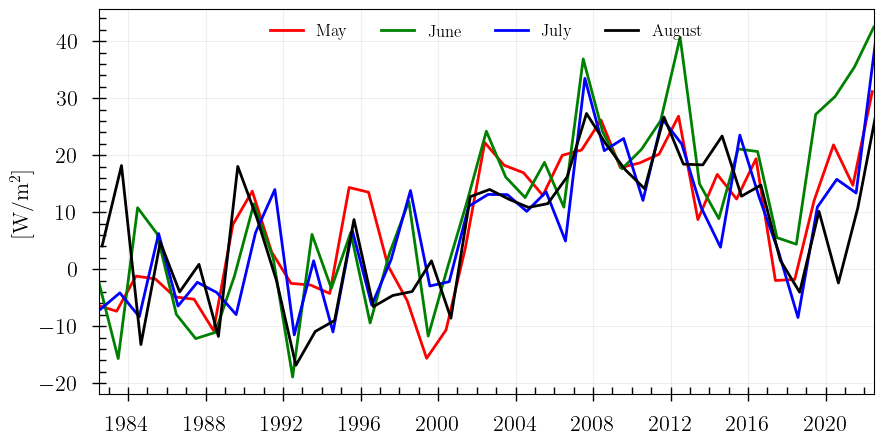

In [59]:
qbar_terms = I_sum + II_sum + I_V_sum + V_sum #+ III_sum

fig, ax  = plt.subplots(figsize=(10,5))


ax.plot(qbar_terms.isel(time=(qbar_terms.groupby('time.month').groups)[5]).time, qbar_terms.isel(time=(qbar_terms.groupby('time.month').groups)[5]), c='r', lw=2, label='May')
ax.plot(qbar_terms.isel(time=(qbar_terms.groupby('time.month').groups)[6]).time, qbar_terms.isel(time=(qbar_terms.groupby('time.month').groups)[6]), c='g', lw=2,label='June')
ax.plot(qbar_terms.isel(time=(qbar_terms.groupby('time.month').groups)[7]).time, qbar_terms.isel(time=(qbar_terms.groupby('time.month').groups)[7]), c='b', lw=2,label='July')
ax.plot(qbar_terms.isel(time=(qbar_terms.groupby('time.month').groups)[8]).time, qbar_terms.isel(time=(qbar_terms.groupby('time.month').groups)[8]), c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='upper center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(qbar_terms.isel(time=(qbar_terms.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            qbar_terms.isel(time=(qbar_terms.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))


ax.set_ylabel(r' [W/m$^2$]', fontsize=16)

# plt.savefig('figs/total_marika_70N.png', format='png', bbox_inches='tight', dpi=300)


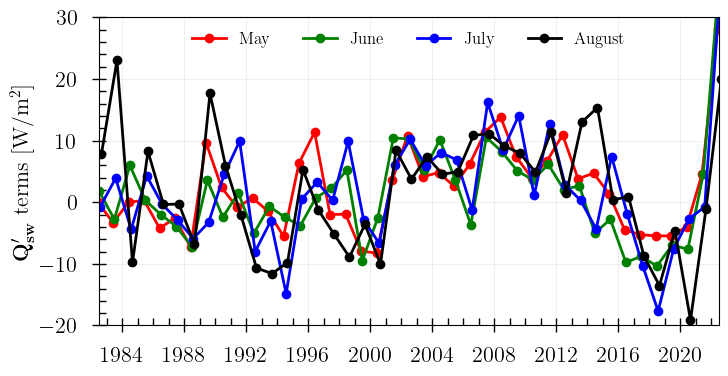

In [90]:
qprime_terms = I_V_sum + V_sum 

fig, ax  = plt.subplots(figsize=(8,4))


ax.plot(qprime_terms.isel(time=(qprime_terms.groupby('time.month').groups)[5]).time, qprime_terms.isel(time=(qprime_terms.groupby('time.month').groups)[5]), '-o', c='r', lw=2, label='May')
ax.plot(qprime_terms.isel(time=(qprime_terms.groupby('time.month').groups)[6]).time, qprime_terms.isel(time=(qprime_terms.groupby('time.month').groups)[6]), '-o',c='g', lw=2,label='June')
ax.plot(qprime_terms.isel(time=(qprime_terms.groupby('time.month').groups)[7]).time, qprime_terms.isel(time=(qprime_terms.groupby('time.month').groups)[7]), '-o',c='b', lw=2,label='July')
ax.plot(qprime_terms.isel(time=(qprime_terms.groupby('time.month').groups)[8]).time, qprime_terms.isel(time=(qprime_terms.groupby('time.month').groups)[8]), '-o',c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='upper center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(qprime_terms.isel(time=(qprime_terms.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            qprime_terms.isel(time=(qprime_terms.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))

ax.set_ylim(-20,30)

ax.set_ylabel(r'$\mathbf{Q_{sw}^\prime}$ terms [W/m$^2$]', fontsize=16)

plt.savefig('../figs/qprime_terms_Marika_70N.png', format='png', bbox_inches='tight', dpi=300)


Text(0, 0.5, '$\\mathbf{Q_{sw}^\\prime}$ higher order terms [W/m$^2$]')

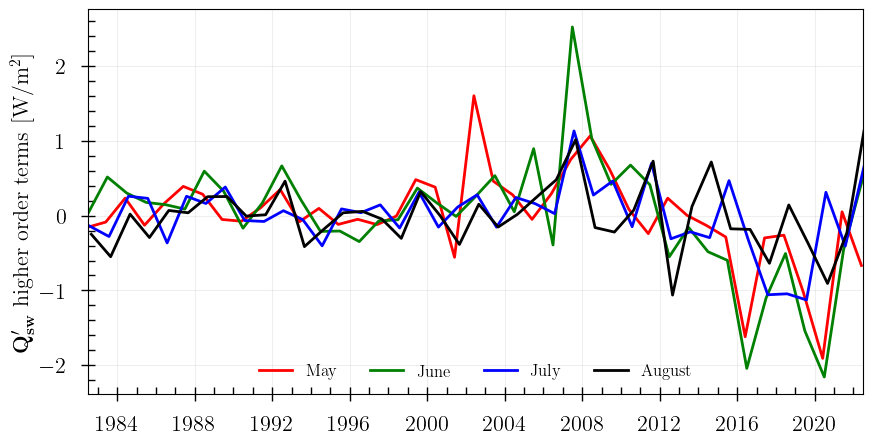

In [61]:
qprime_SO_terms = V_I_sum + V_II_sum + V_III_sum 

fig, ax  = plt.subplots(figsize=(10,5))



ax.plot(qprime_SO_terms.isel(time=(qprime_SO_terms.groupby('time.month').groups)[5]).time, qprime_SO_terms.isel(time=(qprime_SO_terms.groupby('time.month').groups)[5]), c='r', lw=2, label='May')
ax.plot(qprime_SO_terms.isel(time=(qprime_SO_terms.groupby('time.month').groups)[6]).time, qprime_SO_terms.isel(time=(qprime_SO_terms.groupby('time.month').groups)[6]), c='g', lw=2,label='June')
ax.plot(qprime_SO_terms.isel(time=(qprime_SO_terms.groupby('time.month').groups)[7]).time, qprime_SO_terms.isel(time=(qprime_SO_terms.groupby('time.month').groups)[7]), c='b', lw=2,label='July')
ax.plot(qprime_SO_terms.isel(time=(qprime_SO_terms.groupby('time.month').groups)[8]).time, qprime_SO_terms.isel(time=(qprime_SO_terms.groupby('time.month').groups)[8]), c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='lower center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(qprime_SO_terms.isel(time=(qprime_SO_terms.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            qprime_SO_terms.isel(time=(qprime_SO_terms.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))


ax.set_ylabel(r'$\mathbf{Q_{sw}^\prime}$ higher order terms [W/m$^2$]', fontsize=16)

# plt.savefig('figs/qprime_SO_terms.png', format='png', bbox_inches='tight', dpi=300)


### Saving the terms

In [62]:
ds_merged = xr.merge([I_sum.to_dataset(name='I'), II_sum.to_dataset(name='II'), III_sum.to_dataset(name='III'), I_V_sum.to_dataset(name='IV'),
         V_sum.to_dataset(name='V'), V_I_sum.to_dataset(name='VI'), V_II_sum.to_dataset(name='VII'), V_III_sum.to_dataset(name='VIII')])

Text(0, 0.5, 'I+II [W/m$^2$]')

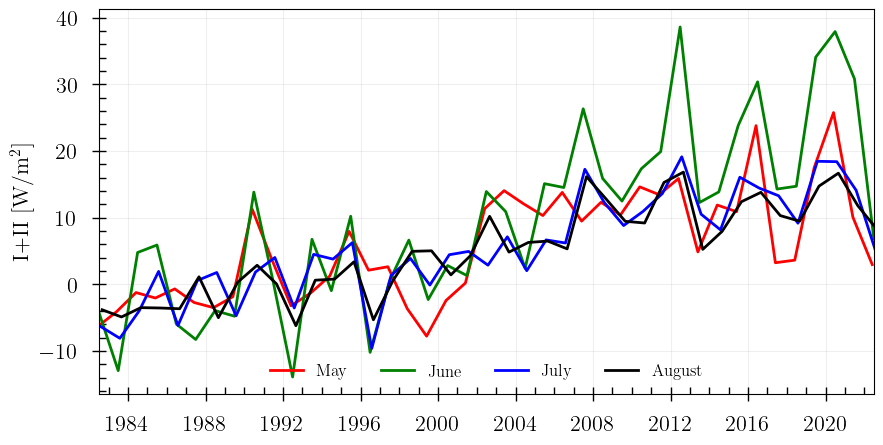

In [63]:
q_tot = ds_merged.I + ds_merged.II #+ ds_merged.III + ds_merged.IV + ds_merged.V + ds_merged.VI + ds_merged.VII + ds_merged.VIII  

fig, ax  = plt.subplots(figsize=(10,5))

ax.plot(q_tot.isel(time=(q_tot.groupby('time.month').groups)[5]).time, q_tot.isel(time=(q_tot.groupby('time.month').groups)[5]), c='r', lw=2, label='May')
ax.plot(q_tot.isel(time=(q_tot.groupby('time.month').groups)[6]).time, q_tot.isel(time=(q_tot.groupby('time.month').groups)[6]), c='g', lw=2,label='June')
ax.plot(q_tot.isel(time=(q_tot.groupby('time.month').groups)[7]).time, q_tot.isel(time=(q_tot.groupby('time.month').groups)[7]), c='b', lw=2,label='July')
ax.plot(q_tot.isel(time=(q_tot.groupby('time.month').groups)[8]).time, q_tot.isel(time=(q_tot.groupby('time.month').groups)[8]), c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='lower center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(q_tot.isel(time=(q_tot.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            q_tot.isel(time=(q_tot.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))


ax.set_ylabel(r'I+II [W/m$^2$]', fontsize=16)

# plt.savefig('figs/I_plus_II.png', format='png', bbox_inches='tight', dpi=300)


Text(0, 0.5, ' [W/m$^2$]')

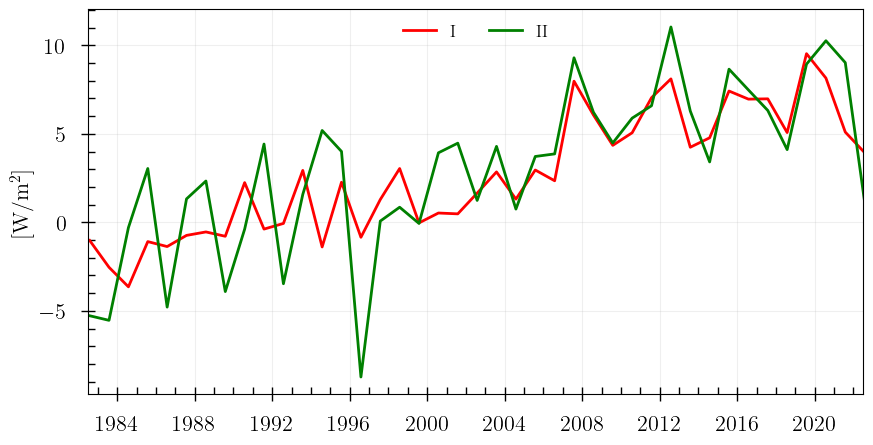

In [64]:
fig, ax  = plt.subplots(figsize=(10,5))


ax.plot(ds_merged.I.isel(time=(ds_merged.I.groupby('time.month').groups)[7]).time, ds_merged.I.isel(time=(ds_merged.I.groupby('time.month').groups)[7]), c='r', lw=2, label='I')
ax.plot(ds_merged.II.isel(time=(ds_merged.II.groupby('time.month').groups)[7]).time, ds_merged.II.isel(time=(ds_merged.II.groupby('time.month').groups)[7]), c='g', lw=2,label='II')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='upper center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(q_tot.isel(time=(q_tot.groupby('time.month').groups)[6]).time.sel(time='1920-01', method='nearest'),
            q_tot.isel(time=(q_tot.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))


ax.set_ylabel(r' [W/m$^2$]', fontsize=16)

# plt.savefig('figs/I_II_july.png', format='png', bbox_inches='tight', dpi=300)


In [65]:
# ds_merged.to_netcdf('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/warming_terms_obs.nc')